**Инициализация**

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [17]:
import os
import pickle
from pathlib import Path

import boto3
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import scipy.sparse
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from implicit.als import AlternatingLeastSquares
import sklearn.metrics
from catboost import CatBoostClassifier, Pool
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)

DATA_DIR = Path("data")
TRACKS_PATH = DATA_DIR / "tracks.parquet"
CATALOG_NAMES_PATH = DATA_DIR / "catalog_names.parquet"
INTERACTIONS_PATH = DATA_DIR / "interactions.parquet"

OUTPUT_DIR = Path("recsys/data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RECOMMENDATIONS_DIR = Path("recsys/recommendations")
RECOMMENDATIONS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
DEBUG = False
DEBUG_ROWS_SUBSET = 50_000
PROD_ROWS_SUBSET = 25_000_000

### **=== ЭТАП 1 ===**

**Загрузка первичных данных**

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [18]:
tracks = pd.read_parquet(TRACKS_PATH)
catalog_names = pd.read_parquet(CATALOG_NAMES_PATH)
interactions = pd.read_parquet(INTERACTIONS_PATH)

rows_limit = DEBUG_ROWS_SUBSET if DEBUG else PROD_ROWS_SUBSET
interactions = interactions.sample(
    n=min(rows_limit, len(interactions)), random_state=RANDOM_STATE
)
track_ids = interactions["track_id"].unique()
tracks = tracks[tracks["track_id"].isin(track_ids)]
catalog_by_type = {
    t: catalog_names[catalog_names["type"] == t]
    for t in ["album", "artist", "genre"]
}
catalog_by_type["track"] = catalog_names[catalog_names["type"] == "track"]
album_ids = tracks["albums"].explode().dropna()
artist_ids = tracks["artists"].explode().dropna()
genre_ids = tracks["genres"].explode().dropna()
catalog_by_type["track"] = catalog_by_type["track"][
    catalog_by_type["track"]["id"].isin(track_ids)
]
catalog_by_type["album"] = catalog_by_type["album"][
    catalog_by_type["album"]["id"].isin(album_ids)
]
catalog_by_type["artist"] = catalog_by_type["artist"][
    catalog_by_type["artist"]["id"].isin(artist_ids)
]
catalog_by_type["genre"] = catalog_by_type["genre"][
    catalog_by_type["genre"]["id"].isin(genre_ids)
]
catalog_names = pd.concat(catalog_by_type.values(), ignore_index=True)
print(
    f"Subset: interactions={len(interactions)}, tracks={len(tracks)}, catalog_names={len(catalog_names)} (limit={rows_limit})"
)

print("tracks:", tracks.shape)
print("catalog_names:", catalog_names.shape)
print("interactions:", interactions.shape)

display(tracks.sample(5, random_state=RANDOM_STATE))
display(catalog_names.sample(5, random_state=RANDOM_STATE))
display(interactions.sample(5, random_state=RANDOM_STATE))

Subset: interactions=25000000, tracks=818120, catalog_names=1525060 (limit=25000000)
tracks: (818120, 4)
catalog_names: (1525060, 3)
interactions: (25000000, 4)


,track_id,albums,artists,genres
145929,3599204,[389913],[161247],"[11, 20]"
777504,60068128,"[9249586, 12307299]",[8400499],"[14, 102]"
308062,19969582,[2250731],[587011],"[2, 102]"
557354,38329682,[3823759],"[6108516, 6877349]","[44, 75]"
591399,40965589,[5342855],[5867420],[28]


,id,type,name
1102607,33326520,track,Морячка
334633,6809320,album,Risk
944115,18490055,track,Принцесса
33388,98713,album,Best Of Adrian
1228765,44550523,track,Time Only Knows


,user_id,track_id,track_seq,started_at
362,19502,10351785,363,2022-03-30
1001,487049,97432785,1002,2022-12-29
110,793792,76979,111,2022-03-12
295,1220121,71971290,296,2022-12-15
12,452617,75871,13,2022-08-05


### **Обзор данных**

Проверяем данные, есть ли с ними явные проблемы.

In [19]:
# Базовый обзор: типы, пропуски, уникальные значения
def df_overview(df: pd.DataFrame, name: str, id_cols=None):
    print(f"=== {name} ===")
    df.info()
    print()
    print("shape:", df.shape)
    print()
    na = df.isna().mean().sort_values(ascending=False)
    print("NA share (top-20):")
    display(na.head(20))
    if id_cols:
        n_combo = df[id_cols].drop_duplicates().shape[0]
        print(f"nunique({id_cols}) = {n_combo}")
    print()

df_overview(tracks, "tracks", id_cols=["track_id"])
df_overview(catalog_names, "catalog_names", id_cols=["id", "type"])
df_overview(interactions, "interactions", id_cols=["user_id", "track_id"])


=== tracks ===
<class 'pandas.core.frame.DataFrame'>
Index: 818120 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   track_id  818120 non-null  int64 
 1   albums    818120 non-null  object
 2   artists   818120 non-null  object
 3   genres    818120 non-null  object
dtypes: int64(1), object(3)
memory usage: 31.2+ MB

shape: (818120, 4)

NA share (top-20):


track_id    0.0
albums      0.0
artists     0.0
genres      0.0
dtype: float64

nunique(['track_id']) = 818120

=== catalog_names ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1525060 entries, 0 to 1525059
Data columns (total 3 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   id      1525060 non-null  int64 
 1   type    1525060 non-null  object
 2   name    1525060 non-null  object
dtypes: int64(1), object(2)
memory usage: 34.9+ MB

shape: (1525060, 3)

NA share (top-20):


id      0.0
type    0.0
name    0.0
dtype: float64

nunique(['id', 'type']) = 1525060

=== interactions ===
<class 'pandas.core.frame.DataFrame'>
Index: 25000000 entries, 130 to 192
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 619.9 MB

shape: (25000000, 4)

NA share (top-20):


user_id       0.0
track_id      0.0
track_seq     0.0
started_at    0.0
dtype: float64

nunique(['user_id', 'track_id']) = 25000000



**Проверка связей между таблицами и диапазон дат**

Проверяем «битые» ссылки (interactions → tracks, tracks → catalog_names) и диапазон дат в `interactions.started_at`.

In [20]:
# 1) Broken links: interactions -> tracks (left join, count NaN)
merged_inter = interactions.merge(
    tracks[["track_id"]].assign(_linked=1), on="track_id", how="left"
)
n_inter_broken = merged_inter["_linked"].isna().sum()
print(
    "Interactions with track_id not in tracks (join):",
    n_inter_broken,
    f"({n_inter_broken/len(interactions):.4%})",
)

# 2) Broken links: tracks -> catalog_names (left join, count NaN ids)
for ref_type, col in tqdm([
    ("artist", "artists"),
    ("album", "albums"),
    ("genre", "genres"),
], desc="Broken links check"):
    if col not in tracks.columns:
        continue
    catalog_type = catalog_names.loc[
        catalog_names["type"] == ref_type, ["id", "name"]
    ]
    exploded = (
        tracks[["track_id", col]]
        .explode(col)
        .dropna(subset=[col])
        .rename(columns={col: "id"})
    )
    merged = exploded.merge(catalog_type, on="id", how="left")
    n_broken = merged["name"].isna().sum()
    print(
        f"Tracks {col} ids not in catalog_names (type={ref_type}, join):",
        f"{n_broken} rows",
    )

# 3) Date range for interactions.started_at (already datetime)
if "started_at" in interactions.columns:
    started = interactions["started_at"]
    print(
        "interactions.started_at range:",
        started.min(),
        "->",
        started.max(),
    )
    print(
        "started_at NA count:",
        started.isna().sum(),
        f"({started.isna().mean():.4%})",
    )

Interactions with track_id not in tracks (join): 0 (0.0000%)


Broken links check:  33%|███▎      | 1/3 [00:02<00:04,  2.31s/it]

Tracks artists ids not in catalog_names (type=artist, join): 0 rows


Broken links check:  67%|██████▋   | 2/3 [00:05<00:03,  3.09s/it]

Tracks albums ids not in catalog_names (type=album, join): 0 rows


Broken links check: 100%|██████████| 3/3 [00:07<00:00,  2.61s/it]

Tracks genres ids not in catalog_names (type=genre, join): 39737 rows


interactions.started_at range: 2022-01-01 00:00:00 -> 2022-12-31 00:00:00
started_at NA count: 0 (0.0000%)


**Выводы**

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

### **=== ЭТАП 2 ===**

**EDA**

Распределение количества прослушанных треков.

count    1.304596e+06
mean     1.916302e+01
std      4.044895e+01
min      1.000000e+00
50%      7.000000e+00
90%      4.600000e+01
95%      7.600000e+01
99%      1.820000e+02
max      1.830000e+03
Name: n_events, dtype: float64

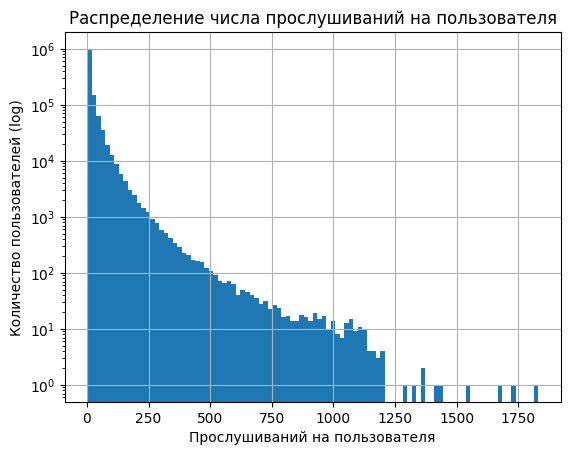

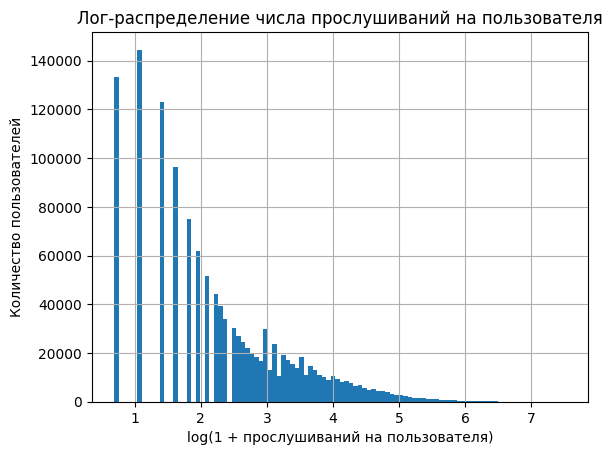

In [21]:
# Распределение количества прослушиваний (интеракций) на пользователя
user_cnt = (
    interactions.groupby("user_id")["track_id"].size().rename("n_events")
)
display(user_cnt.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

plt.figure()
user_cnt.hist(bins=100)
plt.yscale("log")
plt.xlabel("Прослушиваний на пользователя")
plt.ylabel("Количество пользователей (log)")
plt.title("Распределение числа прослушиваний на пользователя")
plt.show()

plt.figure()
np.log1p(user_cnt).hist(bins=100)
plt.xlabel("log(1 + прослушиваний на пользователя)")
plt.ylabel("Количество пользователей")
plt.title("Лог-распределение числа прослушиваний на пользователя")
plt.show()


Наиболее популярные треки

In [22]:
def top_by_events(
    interactions,
    catalog_names,
    tracks=None,
    *,
    item_col,
    catalog_type,
    explode_col=None,
    name_col=None,
    top_k=20,
    top_pct=0.01,
):
    """
    Топ сущностей по числу событий.
    """
    if explode_col is None:
        count_series = (
            interactions.groupby(item_col).size().sort_values(ascending=False)
        )
        group_col = item_col
    else:
        merged = interactions.merge(
            tracks[["track_id", explode_col]], on="track_id", how="left"
        )
        exploded = merged.explode(explode_col).dropna(subset=[explode_col])
        exploded[explode_col] = pd.to_numeric(
            exploded[explode_col], errors="coerce"
        )
        exploded = exploded.dropna(subset=[explode_col])
        exploded[explode_col] = exploded[explode_col].astype("int64")
        count_series = (
            exploded.groupby(explode_col).size().sort_values(ascending=False)
        )
        group_col = explode_col

    top = count_series.head(top_k).reset_index()
    top.columns = [group_col, "n_events"]

    catalog_ref = catalog_names.loc[
        catalog_names["type"] == catalog_type, ["id", "name"]
    ]
    top = top.merge(
        catalog_ref.rename(columns={"id": group_col}),
        on=group_col,
        how="left",
    )
    out_name = name_col if name_col else f"{catalog_type}_name"
    top = top.rename(columns={"name": out_name})

    n_top = max(1, int(top_pct * len(count_series)))
    share = count_series.head(n_top).sum() / count_series.sum()
    return top, count_series, share


# Наиболее популярные треки
top_tracks, track_pop, share_top1pct = top_by_events(
    interactions,
    catalog_names,
    item_col="track_id",
    catalog_type="track",
    top_k=20,
    top_pct=0.01,
)
display(top_tracks)
print(f"Share of events covered by top 1% tracks: {share_top1pct:.2%}")

,track_id,n_events,track_name
0,53404,12376,Smells Like Teen Spirit
1,33311009,12130,Believer
2,178529,11470,Numb
3,35505245,11088,I Got Love
4,65851540,9967,Юность
5,32947997,9716,Shape of You
6,795836,9701,Shape Of My Heart
7,24692821,9640,Way Down We Go
8,51241318,9625,In The End
9,60292250,9546,Blinding Lights


Share of events covered by top 1% tracks: 40.76%


Наиболее популярные жанры

In [23]:
top_genres, genre_pop, share_top1pct_genres = top_by_events(
    interactions,
    catalog_names,
    tracks=tracks,
    item_col="genres",
    catalog_type="genre",
    explode_col="genres",
    name_col="genre_name",
    top_k=20,
    top_pct=0.01,
)
display(top_genres)
print(
    f"Share of events covered by top 1% genres: {share_top1pct_genres:.2%}"
)


,genres,n_events,genre_name
0,11,6239597,pop
1,75,4246086,rap
2,102,3492728,allrock
3,20,2990469,ruspop
4,3,2841688,rusrap
5,68,2256880,electronics
6,16,1828214,dance
7,2,1479864,rusrock
8,14,1433831,rock
9,47,1396933,metal


Share of events covered by top 1% genres: 14.75%


Треки, которые никто не прослушал

In [24]:
listened_tracks = set(interactions["track_id"].unique().tolist())
all_tracks = set(tracks["track_id"].unique().tolist())
never_listened = sorted(list(all_tracks - listened_tracks))

print(
    "Tracks never listened:",
    len(never_listened),
    f"({len(never_listened)/len(all_tracks):.2%} of catalog tracks)",
)

track_name_map = (
    catalog_names.loc[catalog_names["type"] == "track", ["id", "name"]]
    .set_index("id")["name"]
    .to_dict()
)
display(
    pd.DataFrame({
        "track_id": never_listened[:20],
        "track_name": [track_name_map.get(t) for t in never_listened[:20]],
    })
)

Tracks never listened: 0 (0.00% of catalog tracks)


,track_id,track_name


### **Преобразование данных**

In [25]:
track_names = (
    catalog_names.loc[catalog_names["type"] == "track", ["id", "name"]]
    .rename(columns={"id": "track_id", "name": "track_name"})
)
items = tracks.merge(track_names, on="track_id", how="left")

events = (
    interactions.sort_values(["user_id", "started_at"])
    .reset_index(drop=True)
)

# Label encoding for user_id and track_id (fit on full events for consistent indices)
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()
user_encoder.fit(events["user_id"])
item_encoder.fit(events["track_id"])
events["user_id_enc"] = user_encoder.transform(events["user_id"])
events["track_id_enc"] = item_encoder.transform(events["track_id"])
items["track_id_enc"] = item_encoder.transform(items["track_id"])

print("items:", items.shape)
print("events:", events.shape)
display(items.head())
display(events.head())

items: (818120, 6)
events: (25000000, 6)


,track_id,albums,artists,genres,track_name,track_id_enc
0,26,"[3, 2490753]",[16],"[11, 21]",Complimentary Me,0
1,38,"[3, 2490753]",[16],"[11, 21]",Momma's Boy,1
2,135,"[12, 214, 2490809]",[84],[11],Atticus,2
3,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11],Don't Upset The Rhythm (Go Baby Go),3
4,140,"[12, 214, 2490809]",[84],[11],Sometimes,4


,user_id,track_id,track_seq,started_at,user_id_enc,track_id_enc
0,0,597199,8,2022-07-25,0,52082
1,0,1750835,9,2022-07-30,0,94308
2,0,2212520,11,2022-08-07,0,102853
3,0,18042047,23,2022-09-12,0,232793
4,0,18102829,24,2022-09-13,0,233708


### **Сохранение данных**

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [26]:
# Сохранение данных (локально) + (опционально) в S3
load_dotenv()
s3_bucket = os.environ.get("S3_BUCKET_NAME")
s3_access_key = os.environ.get("AWS_ACCESS_KEY_ID")
s3_secret_access_key = os.environ.get("AWS_SECRET_ACCESS_KEY")

items_out = OUTPUT_DIR / "items.parquet"
events_out = OUTPUT_DIR / "events.parquet"

items.to_parquet(items_out, index=False)
events.to_parquet(events_out, index=False)

encoders_path = OUTPUT_DIR / "encoders.pkl"
with open(encoders_path, "wb") as f:
    pickle.dump({"user_encoder": user_encoder, "item_encoder": item_encoder}, f)

print("Saved locally:")
print(" -", items_out.resolve())
print(" -", events_out.resolve())

# if s3_bucket and s3_access_key and s3_secret_access_key:
#     s3_prefix = "recsys/data"
#     client = boto3.client(
#         "s3",
#         aws_access_key_id=s3_access_key,
#         aws_secret_access_key=s3_secret_access_key,
#     )
#     client.upload_file(
#         str(items_out), s3_bucket, f"{s3_prefix}/items.parquet"
#     )
#     client.upload_file(
#         str(events_out), s3_bucket, f"{s3_prefix}/events.parquet"
#     )
#     print(f"Uploaded to s3://{s3_bucket}/{s3_prefix}/")
# else:
#     print(
#         "S3 creds not set (S3_BUCKET_NAME, AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY)"
#         " -> skip S3 upload"
#     )


Saved locally:
 - C:\Users\Selecty\Desktop\leroy\yandex-mle\mle-project-sprint-4-v001\recsys\data\items.parquet
 - C:\Users\Selecty\Desktop\leroy\yandex-mle\mle-project-sprint-4-v001\recsys\data\events.parquet


### **Очистка памяти**

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [27]:
# Очистка памяти: удаляем датафреймы этапов 1–2, данные для моделирования будут загружены из S3
del tracks, catalog_names, interactions, items, events
gc.collect()

8594

### **=== ЭТАП 3 ===**

**Загрузка данных**

Если необходимо, то загружаем items.parquet, events.parquet.

In [28]:
# Загрузка подготовленных данных
items_path = OUTPUT_DIR / "items.parquet"
events_path = OUTPUT_DIR / "events.parquet"

items = pd.read_parquet(items_path)
events = pd.read_parquet(events_path)

print("items:", items.shape)
print("events:", events.shape)
display(items.head())
display(events.head())


items: (818120, 6)
events: (25000000, 6)


,track_id,albums,artists,genres,track_name,track_id_enc
0,26,"[3, 2490753]",[16],"[11, 21]",Complimentary Me,0
1,38,"[3, 2490753]",[16],"[11, 21]",Momma's Boy,1
2,135,"[12, 214, 2490809]",[84],[11],Atticus,2
3,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11],Don't Upset The Rhythm (Go Baby Go),3
4,140,"[12, 214, 2490809]",[84],[11],Sometimes,4


,user_id,track_id,track_seq,started_at,user_id_enc,track_id_enc
0,0,597199,8,2022-07-25,0,52082
1,0,1750835,9,2022-07-30,0,94308
2,0,2212520,11,2022-08-07,0,102853
3,0,18042047,23,2022-09-12,0,232793
4,0,18102829,24,2022-09-13,0,233708


### **Разбиение данных**

Разбиваем данные на тренировочную, тестовую выборки.

In [29]:
SPLIT_DATE = "2022-12-16"
train_events = events[events["started_at"] < SPLIT_DATE]
test_events = events[events["started_at"] >= SPLIT_DATE]
print("train_events:", train_events.shape)
print("test_events:", test_events.shape)

train_events: (23439360, 6)
test_events: (1560640, 6)


### **RecSys**

### **Топ популярных**

Рассчитаем рекомендации как топ популярных.

In [30]:
# Top Popular: robust popularity = reach (users) × engagement (track_seq)
# lower seq = stronger signal
TOP_N = 100

# Per-user max track_seq so engagement is relative to each user's history (early vs late)
max_seq_per_user = (
    train_events.groupby("user_id")["track_seq"].transform("max").clip(lower=1)
)
_train = train_events.assign(
    engagement=1.0 / (1.0 + train_events["track_seq"] / max_seq_per_user)
)

item_popularity = (
    _train.groupby("track_id")
    .agg(users=("user_id", "nunique"), avg_engagement=("engagement", "mean"))
    .reset_index()
    .rename(columns={"track_id": "item_id"})
)

# Scale
scaler = MinMaxScaler()
item_popularity[["users_norm", "avg_engagement_norm"]] = scaler.fit_transform(
    item_popularity[["users", "avg_engagement"]]
)
item_popularity["popularity_score"] = (
    item_popularity["users_norm"] * item_popularity["avg_engagement_norm"]
)
item_popularity = item_popularity.sort_values("popularity_score", ascending=False)

item_popularity_top = item_popularity.head(TOP_N)[['item_id', 'popularity_score']].rename(
    columns={'popularity_score': 'score'}
).reset_index(drop=True)

item_popularity_top.to_parquet(RECOMMENDATIONS_DIR / "cold_recs.parquet", index=False)
print(f"Saved cold_recs to parquet: {len(item_popularity_top)} rows")

Saved cold_recs to parquet: 100 rows


In [31]:
# Display TOPN cold_start recs
top_items_with_name = item_popularity.merge(
    items[["track_id", "track_name"]].rename(columns={"track_id": "item_id"}),
    on="item_id",
    how="left",
)

top_items_with_name = top_items_with_name[
    ["item_id", "track_name", "users", "avg_engagement", "popularity_score"]
]

with pd.option_context("display.max_rows", 10):
    display(top_items_with_name.head(10))

,item_id,track_name,users,avg_engagement,popularity_score
0,53404,Smells Like Teen Spirit,12261,0.938201,0.876861
1,178529,Numb,11345,0.896069,0.733337
2,37384,Zombie,8972,0.951150,0.660585
3,48951,It's My Life,8014,0.938775,0.573857
4,328683,Bring Me To Life,8361,0.878981,0.517119
5,137670,Gangsta's Paradise,7099,0.921555,0.488379
6,795836,Shape Of My Heart,9546,0.812673,0.487116
7,148345,Californication,7411,0.897329,0.480546
8,52100,Don't Speak,6476,0.930481,0.454947
9,10216,Wind Of Change,5703,0.972592,0.439825


### **Персональные**

Рассчитаем персональные рекомендации.

In [32]:
# 3.2 Personal Recommendations (ALS)

# Prepare data for ALS: create user-item matrix
# Load encoders saved during data preparation (Stage 1)
encoders_path = OUTPUT_DIR / "encoders.pkl"
with open(encoders_path, "rb") as f:
    encoders = pickle.load(f)
user_encoder = encoders["user_encoder"]
item_encoder = encoders["item_encoder"]
unique_users = user_encoder.classes_
unique_items = item_encoder.classes_

# Add encoded columns for direct matrix construction
events_train = train_events.copy()
events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"])
events_train["item_id_enc"] = item_encoder.transform(events_train["track_id"])
events_train["rating"] = 1.0  # Binary implicit feedback

# Create CSR matrix directly
user_item_matrix = scipy.sparse.csr_matrix(
    (
        events_train["rating"].values,
        (events_train["user_id_enc"].values, events_train["item_id_enc"].values),
    ),
    shape=(len(unique_users), len(unique_items)),
    dtype=np.float32,
)

print(f"User-item matrix shape: {user_item_matrix.shape}")
print(f"Non-zero entries: {user_item_matrix.nnz}")

# Train ALS model
als_model = AlternatingLeastSquares(
    factors=50,
    regularization=0.1,
    iterations=15,
    random_state=RANDOM_STATE,
    num_threads=4
)

print("Training ALS model...")
als_model.fit(user_item_matrix)
print("ALS model trained successfully")

# Generate recommendations for train users (candidates for CatBoost ranker)
train_users_recommend = train_events["user_id"].unique()
user_ids_encoded = user_encoder.transform(train_users_recommend)

item_ids_enc, als_scores = als_model.recommend(
    user_ids_encoded,
    user_item_matrix[user_ids_encoded],
    filter_already_liked_items=True,
    N=TOP_N
)

# Convert to DataFrame
als_recommendations = pd.DataFrame({
    "user_id_enc": user_ids_encoded,
    "item_id_enc": [row.tolist() for row in item_ids_enc],
    "score": [row.tolist() for row in als_scores],
})
als_recommendations = als_recommendations.explode(
    ["item_id_enc", "score"], ignore_index=True)
als_recommendations["item_id_enc"] = als_recommendations["item_id_enc"].astype(np.int64)
als_recommendations["score"] = als_recommendations["score"].astype(np.float64)

# Map encoded IDs back to original IDs
als_recommendations["user_id"] = user_encoder.inverse_transform(
    als_recommendations["user_id_enc"])
als_recommendations["item_id"] = item_encoder.inverse_transform(
    als_recommendations["item_id_enc"])
als_recommendations = als_recommendations.drop(
    columns=["user_id_enc", "item_id_enc"])

# Add rank per user
als_recommendations["rank"] = als_recommendations.groupby("user_id").cumcount() + 1
personal_als = als_recommendations[["user_id", "item_id", "score", "rank"]].copy()
personal_als.to_parquet(RECOMMENDATIONS_DIR / "personal_als.parquet", index=False)
print(f"personal_als: {personal_als.shape}, saved to {RECOMMENDATIONS_DIR / 'personal_als.parquet'}")
display(personal_als.head(10))

User-item matrix shape: (1304596, 818120)
Non-zero entries: 23439360


c:\Users\Selecty\anaconda3\envs\recsys\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\Selecty\anaconda3\envs\recsys\Lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: Intel MKL BLAS is configured to use 12 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'MKL_NUM_THREADS=1' or by callng 'threadpoolctl.threadpool_limits(1, "blas")'. Having MKL use a threadpool can lead to severe performance issues
  check_blas_config()


Training ALS model...


100%|██████████| 15/15 [01:43<00:00,  6.92s/it]


ALS model trained successfully
personal_als: (125519700, 4), saved to recsys\recommendations\personal_als.parquet


,user_id,item_id,score,rank
0,0,9047114,0.004055,1
1,0,48591706,0.002626,2
2,0,580880,0.002525,3
3,0,148345,0.002466,4
4,0,560468,0.002405,5
5,0,33308946,0.002323,6
6,0,39089632,0.002140,7
7,0,2192826,0.001909,8
8,0,39307896,0.001823,9
9,0,9282507,0.001677,10


# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [33]:
# Load and Prepare Items for Content Recommendations (use items for DEBUG subset)
items_content = items[
    items["genres"].notna() & (items["genres"].apply(len) > 0)
].copy()

# Sort by track_id
items_content = items_content.sort_values("track_id").reset_index(drop=True)

# Create encoded index
items_content["track_id_enc"] = range(len(items_content))

print(f"Content items (tracks with genres): {len(items_content)}")
items_content.head()


Content items (tracks with genres): 815385


,track_id,albums,artists,genres,track_name,track_id_enc
0,26,"[3, 2490753]",[16],"[11, 21]",Complimentary Me,0
1,38,"[3, 2490753]",[16],"[11, 21]",Momma's Boy,1
2,135,"[12, 214, 2490809]",[84],[11],Atticus,2
3,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11],Don't Upset The Rhythm (Go Baby Go),3
4,140,"[12, 214, 2490809]",[84],[11],Sometimes,4


In [34]:
# Build Genre Vocabulary
def get_genres(items):
    """Build genre frequency table from items. Returns DataFrame with genre_id (index), frequency, and score (normalized)."""
    freq = {}
    for genres_list in items["genres"]:
        for gid in genres_list:
            freq[gid] = freq.get(gid, 0) + 1
    genres = pd.DataFrame({"frequency": freq}).rename_axis("genre_id")
    return genres

genres = get_genres(items_content)
print(f"Unique genres: {len(genres)}")
genres["score"] = genres["frequency"] / genres["frequency"].sum()
genres.sort_values("score", ascending=False).head(10)

Unique genres: 173


,frequency,score
genre_id,,
11,137755,0.101618
75,107805,0.079525
102,97401,0.071850
68,92502,0.068236
47,59998,0.044259
3,57364,0.042316
44,48515,0.035788
14,44134,0.032556
16,42503,0.031353


In [35]:
# Build Track--Genre CSR Matrix
def get_track2genre_matrix(genres, items):
    """Build sparse (num_tracks, num_genres) matrix. Entry = 1 if track has genre."""
    genre_ids = sorted(genres.index.tolist())
    genre2idx = {gid: i for i, gid in enumerate(genre_ids)}
    num_genres = len(genre_ids)
    num_tracks = len(items)

    row_idx, col_idx, data = [], [], []
    for i, genres_list in enumerate(items["genres"]):
        for gid in genres_list:
            if gid in genre2idx:
                row_idx.append(i)
                col_idx.append(genre2idx[gid])
                data.append(1)

    matrix = scipy.sparse.csr_matrix(
        (data, (row_idx, col_idx)),
        shape=(num_tracks, num_genres)
    )
    return normalize(matrix, norm="l1", axis=1)

track_genre_matrix = get_track2genre_matrix(genres, items_content)
print(f"Track-Genre matrix shape: {track_genre_matrix.shape}")

Track-Genre matrix shape: (815385, 173)


In [36]:
def recommend_similar_tracks(track_id, items, track_genre_matrix, k=5):
    """Return top-k similar tracks by genre cosine similarity."""
    match = items.loc[items["track_id"] == track_id, "track_id_enc"]
    if match.empty:
        return pd.DataFrame()
    track_id_enc = match.values[0]
    target_vector = track_genre_matrix[track_id_enc]
    similarity_scores = cosine_similarity(track_genre_matrix, target_vector).flatten()
    similarity_scores[track_id_enc] = -1  # remove self-match
    top_k_indices = np.argsort(similarity_scores)[-k:][::-1]
    similar_tracks = items[items["track_id_enc"].isin(top_k_indices)].copy()
    # attach scores in order
    enc2score = {i: float(similarity_scores[i]) for i in top_k_indices}
    similar_tracks["similarity"] = similar_tracks["track_id_enc"].map(enc2score)
    return similar_tracks[["track_id", "similarity"]].reset_index(drop=True)

# Demo
sample_track = items_content["track_id"].iloc[0]
recs = recommend_similar_tracks(sample_track, items_content, track_genre_matrix, k=5)
print(f"Similar tracks for track_id={sample_track}:")
recs

Similar tracks for track_id=26:


,track_id,similarity
0,91858,1.0
1,262858,1.0
2,262860,1.0
3,4149189,1.0
4,36889290,1.0


In [37]:
# Build content-based recommendations (user seed track -> similar tracks)
TOP_N_CONTENT = 100
# Latest track per user
user_seeds = (
    train_events.sort_values(by=["user_id", "track_seq"], ascending=[True, False])
    .drop_duplicates(subset=["user_id"], keep="first")[["user_id", "track_id"]]
    .rename(columns={"track_id": "seed_track"})
)
seed_tracks = user_seeds["seed_track"].drop_duplicates().values

In [38]:
# Build content-based recommendations (user seed track -> similar tracks)
TOP_N_CONTENT = 100
# Latest track per user
user_seeds = (
    train_events.sort_values(by=["user_id", "track_seq"], ascending=[True, False])
    .drop_duplicates(subset=["user_id"], keep="first")[["user_id", "track_id"]]
    .rename(columns={"track_id": "seed_track"})
)
seed_tracks = user_seeds["seed_track"].drop_duplicates().values
seed_recs = []
for seed_t in tqdm(seed_tracks, desc="Content recs"):
    recs = recommend_similar_tracks(seed_t, items_content, track_genre_matrix, k=TOP_N_CONTENT)
    if recs.empty:
        continue
    for r, (_, row) in enumerate(recs.iterrows(), 1):
        seed_recs.append({"seed_track": seed_t, "rank": r, "item_id": row["track_id"], "score": row["similarity"]})
if len(seed_recs) > 0:
    seed_recs_df = pd.DataFrame(seed_recs)
    content_recs = user_seeds.merge(seed_recs_df, on="seed_track")[["user_id", "item_id", "score", "rank"]]
else:
    content_recs = pd.DataFrame(columns=["user_id", "item_id", "score", "rank"])
content_recs.to_parquet(RECOMMENDATIONS_DIR / "content_recs.parquet", index=False)
print(f"content_recs: {content_recs.shape}, saved to parquet")
test_users_content = content_recs.loc[content_recs["user_id"].isin(test_events["user_id"])]["user_id"].nunique()
print(f"test_users_content: {test_users_content}")

Content recs:  12%|█▏        | 27466/222955 [53:24<6:20:05,  8.57it/s] 


KeyboardInterrupt: 

In [ ]:
# Generate similar tracks for all items and save to parquet
K_SIMILAR = 100
similar_rows = []
track_ids_content = items_content["track_id"].tolist()
for track_id in tqdm(track_ids_content, desc="Similar tracks"):
    recs = recommend_similar_tracks(track_id, items_content, track_genre_matrix, k=K_SIMILAR)
    if recs.empty:
        continue
    for rank, (_, row) in enumerate(recs.iterrows(), start=1):
        similar_rows.append({
            "track_id": track_id,
            "similar_track_id": row["track_id"],
            "score": row["similarity"],
            "rank": rank,
        })
similar_tracks_all = pd.DataFrame(similar_rows)
similar_tracks_all.to_parquet(RECOMMENDATIONS_DIR / "similar.parquet", index=False)
print(f"Saved similar.parquet: {len(similar_tracks_all)} rows")

Similar tracks: 100%|██████████| 32591/32591 [04:14<00:00, 128.23it/s]


Saved similar.parquet: 3259100 rows


### Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [ ]:
split_date_for_labels = pd.to_datetime("2022-12-23").date()

In [ ]:
# User features for ranking
user_activity = train_events.groupby("user_id").size().reset_index(name="user_activity")
user_last_started = train_events.groupby("user_id")["started_at"].max().reset_index(name="user_last_started_at")
ref_date = pd.Timestamp(split_date_for_labels)
user_last_started["days_since_last_user_interaction"] = (
    ref_date - pd.to_datetime(user_last_started["user_last_started_at"])
).dt.days
user_features = user_activity.merge(
    user_last_started[["user_id", "days_since_last_user_interaction"]], on="user_id"
)
days_since_median = user_features["days_since_last_user_interaction"].median()

Фича user_is_cold добавлена далее в проекте

### Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [ ]:
# Split test data for labels and final evaluation
test_started = pd.to_datetime(test_events["started_at"]).dt.date
split_mask = test_started < split_date_for_labels
events_train_candidates = test_events.loc[split_mask].copy()
events_test_candidates = test_events.loc[~split_mask].copy()
events_train_candidates["target"] = 1
print(
    f"events_train_candidates: {len(events_train_candidates)}, "
    f"events_test_candidates: {len(events_test_candidates)}"
)

events_train_candidates: 1642, events_test_candidates: 1541


In [ ]:
# Candidate pool construction (training)
als_recs = pd.read_parquet(RECOMMENDATIONS_DIR / "personal_als.parquet")
content_recs = pd.read_parquet(RECOMMENDATIONS_DIR / "content_recs.parquet")
cold_recs = pd.read_parquet(RECOMMENDATIONS_DIR / "cold_recs.parquet")

# Expand cold_recs (item_id, score) to (user_id, item_id, score) for cold users
train_user_ids = train_events["user_id"].drop_duplicates()
cold_user_ids = events_train_candidates["user_id"].drop_duplicates()
cold_user_ids = cold_user_ids[~cold_user_ids.isin(train_user_ids)]
if len(cold_user_ids) > 0 and len(cold_recs) > 0:
    cold_users_df = pd.DataFrame({"user_id": cold_user_ids.values, "_k": 1})
    cold_items_df = cold_recs.assign(_k=1)
    cold_recs_expanded = cold_users_df.merge(cold_items_df, on="_k").drop(columns=["_k"])[["user_id", "item_id", "score"]]
else:
    cold_recs_expanded = pd.DataFrame(columns=["user_id", "item_id", "score"])

# Merge on user_id, item_id (outer); keep max score when duplicate
c_als = als_recs[["user_id", "item_id", "score"]].rename(columns={"score": "als_score"})
c_cnt = content_recs[["user_id", "item_id", "score"]].rename(columns={"score": "cnt_score"})
c_cold = cold_recs_expanded.rename(columns={"score": "cold_score"})
candidates = c_als.merge(c_cnt, on=["user_id", "item_id"], how="outer")
candidates = candidates.merge(c_cold, on=["user_id", "item_id"], how="outer")
for col in ["als_score", "cnt_score", "cold_score"]:
    candidates[col] = candidates[col].fillna(0)
candidates["score"] = candidates[["als_score", "cnt_score", "cold_score"]].max(axis=1)

# Merge user features (cold users: user_activity=0, user_is_cold=1, days_since=median)
candidates = candidates.merge(user_features, on="user_id", how="left")
candidates["user_activity"] = candidates["user_activity"].fillna(0).astype(int)
candidates["user_is_cold"] = (~candidates["user_id"].isin(train_events["user_id"])).astype(int)
candidates["days_since_last_user_interaction"] = candidates["days_since_last_user_interaction"].fillna(days_since_median)
display(candidates)

,user_id,item_id,als_score,cnt_score,cold_score,score,user_activity,days_since_last_user_interaction,user_is_cold
0,69,78426489.0,0.000018,0.0,0.000000,0.000018,1,227.0,0
1,69,694683.0,0.000015,0.0,0.000000,0.000015,1,227.0,0
2,69,16298499.0,0.000014,0.0,0.000000,0.000014,1,227.0,0
3,69,55909411.0,0.000013,0.0,0.000000,0.000013,1,227.0,0
4,69,29544272.0,0.000012,0.0,0.000000,0.000012,1,227.0,0
...,...,...,...,...,...,...,...,...,...
8697817,1374571,109443.0,0.000000,0.0,0.036545,0.036545,0,101.0,1
8697818,1374571,137670.0,0.000000,0.0,0.036539,0.036539,0,101.0,1
8697819,1374571,512793.0,0.000000,0.0,0.036389,0.036389,0,101.0,1
8697820,1374571,41920901.0,0.000000,0.0,0.036255,0.036255,0,101.0,1


In [ ]:
# Target construction: 1 if user interacted in events_train_candidates, 0 otherwise
events_labels_target = events_train_candidates[["user_id", "track_id"]].drop_duplicates().rename(
    columns={"track_id": "item_id"})
events_labels_target["target"] = 1
candidates = candidates.merge(
    events_labels_target,
    on=["user_id", "item_id"],
    how="left"
)
candidates["target"] = candidates["target"].fillna(0).astype(int)

# Keep only users with at least one positive; sample 4 negatives per user
candidates_to_sample = candidates.groupby("user_id").filter(lambda x: x["target"].sum() > 0)
positives = candidates_to_sample.query("target == 1")
negatives = (
    candidates_to_sample.query("target == 0")
    .groupby("user_id")
    .apply(lambda x: x.sample(min(4, len(x)), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)
candidates_for_train = pd.concat([positives, negatives], ignore_index=True)
print(f"candidates_for_train: {len(candidates_for_train)}, positives: {len(positives)}")

candidates_for_train: 40, positives: 8


In [ ]:
# Feature engineering & 5. Train CatBoost ranking model
features = ["cold_score", "als_score", "cnt_score", "user_activity", "user_is_cold", "days_since_last_user_interaction"]
X = candidates_for_train[features].fillna(0)
y = candidates_for_train["target"]

model = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=False,
)
model.fit(X, y)
print("CatBoost ranking model trained")

CatBoost ranking model trained


In [ ]:
# Candidate pool (inference): ALS + Content + Cold for events_test_candidates users
test_candidates_users = events_test_candidates["user_id"].unique()
c_als = als_recs[als_recs["user_id"].isin(test_candidates_users)][["user_id", "item_id", "score"]].rename(columns={"score": "als_score"})
c_cnt = content_recs[content_recs["user_id"].isin(test_candidates_users)][["user_id", "item_id", "score"]].rename(columns={"score": "cnt_score"})
cold_test_users = pd.Series(test_candidates_users)[~pd.Series(test_candidates_users).isin(train_events["user_id"])]
if len(cold_test_users) > 0 and len(cold_recs) > 0:
    cold_users_df = pd.DataFrame({"user_id": cold_test_users.values, "_k": 1})
    cold_items_df = cold_recs.assign(_k=1)
    c_cold = cold_users_df.merge(cold_items_df, on="_k").drop(columns=["_k"])[["user_id", "item_id", "score"]].rename(columns={"score": "cold_score"})
else:
    c_cold = pd.DataFrame(columns=["user_id", "item_id", "cold_score"])

# Merge
candidates_to_rank = c_als.merge(c_cnt, on=["user_id", "item_id"], how="outer")
candidates_to_rank = candidates_to_rank.merge(c_cold, on=["user_id", "item_id"], how="outer")
for col in ["als_score", "cnt_score", "cold_score"]:
    candidates_to_rank[col] = candidates_to_rank[col].fillna(0)

# Merge user features (cold users: user_activity=0, user_is_cold=1, days_since=median)
candidates_to_rank = candidates_to_rank.merge(user_features, on="user_id", how="left")
candidates_to_rank["user_activity"] = candidates_to_rank["user_activity"].fillna(0).astype(int)
candidates_to_rank["user_is_cold"] = (~candidates_to_rank["user_id"].isin(train_events["user_id"])).astype(int)
candidates_to_rank["days_since_last_user_interaction"] = candidates_to_rank["days_since_last_user_interaction"].fillna(days_since_median)

In [ ]:
# Apply ranking model, sort, top 100 per user
inference_pool = Pool(data=candidates_to_rank[features])
predictions = model.predict_proba(inference_pool)
candidates_to_rank["cb_score"] = predictions[:, 1]

candidates_to_rank = candidates_to_rank.sort_values(
    ["user_id", "cb_score"],
    ascending=[True, False]
)
candidates_to_rank["rank"] = candidates_to_rank.groupby("user_id").cumcount() + 1
final_recommendations = candidates_to_rank.query("rank <= 100").copy()
final_recommendations = final_recommendations.rename(columns={"cb_score": "score"})

# Save to recsys/recommendations/recommendations.parquet
final_out = final_recommendations[["user_id", "item_id", "score", "rank"]]
final_out.to_parquet(RECOMMENDATIONS_DIR / "recommendations.parquet", index=False)
print(f"Saved {len(final_out)} rows to {RECOMMENDATIONS_DIR / 'recommendations.parquet'}")

Saved 153300 rows to recsys\recommendations\recommendations.parquet


# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [ ]:
def recall_precision_at_k(recs_df, gt_dict, users, k):
    """recs_df must have user_id, item_id, and rank or score for ordering."""
    recalls, precisions = [], []
    for u in users:
        gt = gt_dict.get(u)
        if not gt or not isinstance(gt, (set, frozenset)):
            continue
        user_recs = recs_df[recs_df["user_id"] == u]
        if user_recs.empty:
            continue
        if "rank" in user_recs.columns:
            rec_items = user_recs[user_recs["rank"] <= k]["item_id"].tolist()
        else:
            rec_items = user_recs.nlargest(k, "score")["item_id"].tolist()
        rec_items = [int(x) if pd.notna(x) else x for x in rec_items[:k]]
        hits = gt & set(rec_items)
        recalls.append(len(hits) / len(gt))
        precisions.append(len(hits) / k)
    if not recalls:
        return np.nan, np.nan
    return float(np.mean(recalls)), float(np.mean(precisions))


def coverage_at_k(recs_df, all_items, k):
    """Fraction of catalog covered by top-k recommendations. recs_df must have rank column."""
    if "rank" not in recs_df.columns or recs_df.empty:
        return np.nan
    rec_items = set(recs_df[recs_df["rank"] <= k]["item_id"].dropna().astype(int))
    return len(rec_items) / len(all_items) if all_items else np.nan


def novelty_for_items(item_ids, item_prob):
    """Average self-information of recommended items given item_prob dict."""
    ps = [item_prob.get(i, 1e-12) for i in item_ids]
    return float(np.mean([-np.log2(p) for p in ps]))

def compute_ndcg(rating: pd.Series, score: pd.Series, k):
    """ подсчёт ndcg
    rating: истинные оценки
    score: оценки модели
    k: количество айтемов (по убыванию score) для оценки, остальные - отбрасываются
    """
    # если кол-во объектов меньше 2, то NDCG - не определена
    if len(rating) < 2:
        return np.nan

    ndcg = sklearn.metrics.ndcg_score(
        np.asarray([rating.to_numpy()]),
        np.asarray([score.to_numpy()]),
        k=k
    )

    return ndcg

def novelty_at_k(recs_df, item_prob, test_users, k):
    """Compute Novelty@K: mean over test users of mean -log2(p) for top-k recommendations."""
    if "rank" not in recs_df.columns or recs_df.empty:
        return np.nan
    recs_topn = recs_df[recs_df["rank"] <= k].copy()
    recs_topn["item_prob"] = recs_topn["item_id"].apply(
        lambda x: item_prob.get(int(x), 1e-12) if pd.notna(x) else 1e-12
    )
    recs_topn["neg_log2_p"] = -np.log2(recs_topn["item_prob"])
    novelty_per_user = recs_topn[recs_topn["user_id"].isin(test_users)].groupby("user_id")["neg_log2_p"].mean()
    return float(novelty_per_user.mean()) if len(novelty_per_user) > 0 else np.nan

def ndcg_at_k(recs_df, test_events, test_users, k):
    """Compute NDCG@K: merge recs with test ground truth, compute NDCG per user, return mean."""
    test_pairs = test_events[["user_id", "track_id"]].drop_duplicates().rename(columns={"track_id": "item_id"})
    test_pairs["rating_test"] = 1
    recs_with_rating = recs_df.merge(test_pairs, on=["user_id", "item_id"], how="left")
    recs_with_rating["rating_test"] = recs_with_rating["rating_test"].fillna(0).astype(int)
    ndcg_per_user = (
        recs_with_rating[recs_with_rating["user_id"].isin(test_users)]
        .groupby("user_id")
        .apply(lambda x: compute_ndcg(x["rating_test"], x["score"], k=k))
    )
    return float(ndcg_per_user.dropna().mean()) if len(ndcg_per_user.dropna()) > 0 else np.nan

In [ ]:
# Shared: ground truth and item prob for all metrics
test_gt = events_test_candidates.groupby("user_id")["track_id"].apply(set).to_dict()
test_users_list = list(test_gt.keys())
item_counts = train_events.groupby("track_id").size()
item_prob = (item_counts / item_counts.sum()).to_dict()
all_items = set(train_events["track_id"]) | set(events_test_candidates["track_id"])

# Cold users recs metrics (evaluated on events_test_candidates, cold users only)
cold_users = events_test_candidates["user_id"].drop_duplicates()[
    ~events_test_candidates["user_id"].drop_duplicates().isin(train_events["user_id"])
]
cold_users_gt = events_test_candidates[events_test_candidates["user_id"].isin(cold_users)].groupby("user_id")["track_id"].apply(set).to_dict()
if len(cold_users) > 0 and len(cold_recs) > 0:
    cold_users_df = pd.DataFrame({"user_id": cold_users.values, "_k": 1})
    cold_items_df = cold_recs.assign(rank=cold_recs["score"].rank(ascending=False).astype(int)).assign(_k=1)
    cold_recs_eval = cold_users_df.merge(cold_items_df, on="_k").drop(columns=["_k"])[["user_id", "item_id", "score", "rank"]]
    recall_k_cold, precision_k_cold = recall_precision_at_k(cold_recs_eval, cold_users_gt, list(cold_users_gt.keys()), TOP_N)
    all_items_cold = all_items | set(cold_recs["item_id"])
    coverage_k_cold = coverage_at_k(cold_recs_eval, all_items_cold, TOP_N)
    novelty_k_cold = novelty_at_k(cold_recs_eval, item_prob, list(cold_users_gt.keys()), TOP_N)
else:
    recall_k_cold, precision_k_cold, coverage_k_cold, novelty_k_cold = np.nan, np.nan, np.nan, np.nan

print(f"Top Popular — cold users only, K={TOP_N}:")
print(f"  Recall@K:    {recall_k_cold:.4f}")
print(f"  Precision@K: {precision_k_cold:.4f}")
print(f"  Coverage@K:  {coverage_k_cold:.4f}")
print(f"  Novelty@K:   {novelty_k_cold:.4f}")

Top Popular — cold users only, K=100:
  Recall@K:    0.0029
  Precision@K: 0.0000
  Coverage@K:  0.0031
  Novelty@K:   12.6750


In [ ]:
# Evaluation metrics for Personal ALS (evaluated on events_test_candidates, warm users with ALS recs)
als_recs_test = als_recs[als_recs["user_id"].isin(events_test_candidates["user_id"])]
als_users = [u for u in test_users_list if u in als_recs_test["user_id"].values]
if als_users:
    recall_k_als, precision_k_als = recall_precision_at_k(als_recs_test, test_gt, als_users, TOP_N)
    coverage_k_als = coverage_at_k(als_recs_test, all_items, TOP_N)
    novelty_k_als = novelty_at_k(als_recs_test, item_prob, als_users, TOP_N)
    ndcg_k_als = ndcg_at_k(als_recs_test, events_test_candidates, als_users, TOP_N)
else:
    recall_k_als, precision_k_als, coverage_k_als, novelty_k_als, ndcg_k_als = np.nan, np.nan, np.nan, np.nan, np.nan

print(f"Personal ALS — K={TOP_N}:")
print(f"  Recall@K:    {recall_k_als:.4f}")
print(f"  Precision@K: {precision_k_als:.4f}")
print(f"  Coverage@K:  {coverage_k_als:.4f}")
print(f"  Novelty@K:  {novelty_k_als:.4f}")
print(f"  NDCG@K:     {ndcg_k_als:.4f}")

Personal ALS — K=100:
  Recall@K:    0.0000
  Precision@K: 0.0000
  Coverage@K:  0.0112
  Novelty@K:  12.7563
  NDCG@K:     0.0000


In [ ]:
# Content based metrics (evaluated on events_test_candidates, users with content recs)
content_recs_test = content_recs[content_recs["user_id"].isin(events_test_candidates["user_id"])]
content_users = [u for u in test_users_list if u in content_recs_test["user_id"].values]
if content_users:
    recall_k_content, precision_k_content = recall_precision_at_k(content_recs_test, test_gt, content_users, TOP_N_CONTENT)
    coverage_k_content = coverage_at_k(content_recs_test, all_items, TOP_N_CONTENT)
    novelty_k_content = novelty_at_k(content_recs_test, item_prob, content_users, TOP_N_CONTENT)
    ndcg_k_content = ndcg_at_k(content_recs_test, events_test_candidates, content_users, TOP_N_CONTENT)
else:
    recall_k_content, precision_k_content = np.nan, np.nan
    coverage_k_content, novelty_k_content, ndcg_k_content = np.nan, np.nan, np.nan

print(f"Content-Based (genre) — K={TOP_N_CONTENT}:")
print(f"  Recall@K:    {recall_k_content:.4f}")
print(f"  Precision@K: {precision_k_content:.4f}")
print(f"  Coverage@K:  {coverage_k_content:.4f}")
print(f"  Novelty@K:  {novelty_k_content:.4f}")
print(f"  NDCG@K:     {ndcg_k_content:.4f}")

Content-Based (genre) — K=100:
  Recall@K:    0.0000
  Precision@K: 0.0000
  Coverage@K:  0.1834
  Novelty@K:  16.3690
  NDCG@K:     0.0000


In [ ]:
# Final metrics (CatBoost-ranked recommendations on events_test_candidates)
recall_final, precision_final = recall_precision_at_k(final_recommendations, test_gt, test_users_list, 100)
coverage_final = coverage_at_k(final_recommendations, all_items, 100)
novelty_final = novelty_at_k(final_recommendations, item_prob, test_users_list, 100)
ndcg_final = ndcg_at_k(final_recommendations, events_test_candidates, test_users_list, 100)

print(f"Final (CatBoost ranked) — K=100:")
print(f"  Recall@K:    {recall_final:.4f}")
print(f"  Precision@K: {precision_final:.4f}")
print(f"  Coverage@K:  {coverage_final:.4f}")
print(f"  Novelty@K:  {novelty_final:.4f}")
print(f"  NDCG@K:     {ndcg_final:.4f}")

Final (CatBoost ranked) — K=100:
  Recall@K:    0.0026
  Precision@K: 0.0000
  Coverage@K:  0.1862
  Novelty@K:  13.0124
  NDCG@K:     0.0005


# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

In [ ]:
# Выводы по проделанной работе (заполните по результатам ваших запусков):
# 1) Какие проблемы данных нашли на Этапе 1 и как исправили?
# 2) Какие инсайты по распределениям на Этапе 2?
# 3) Какой baseline лучше по метрикам и почему?


In [ ]:
# Здесь можно добавить финальные таблицы/графики или текстовые выводы.
